In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
df_train = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv")

In [3]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


In [5]:
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [6]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

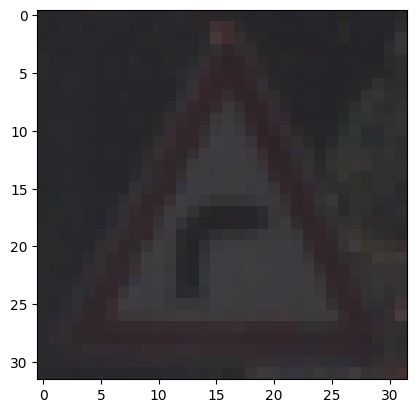

In [7]:
plt.imshow(X_train[20])
plt.show()

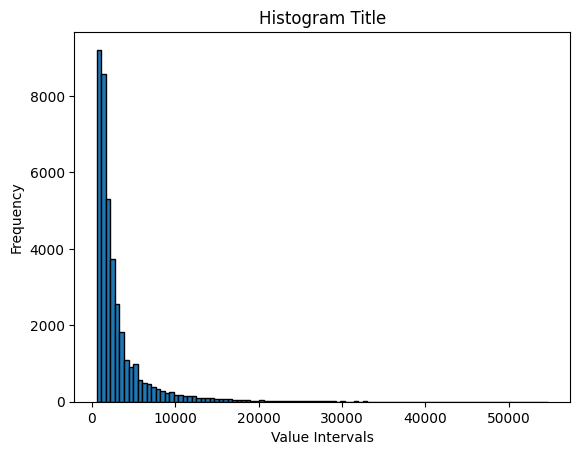

In [8]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()